In [41]:
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from mplfinance.original_flavor import candlestick_ohlc

import pandas as pd
import numpy as np

from Functions import *

### Plotting Indicators

In [42]:
def plot_candlesticks(df, df_with_mfi, df_with_rsi, symbol: str, period=14):

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 9), sharex=True, gridspec_kw={'height_ratios': [3, 2, 2]})

    # Prepare data for candlestick
    quotes = []
    for idx, (multi_idx, row) in enumerate(df.iterrows()):
        timestamp = multi_idx[1]
        quotes.append((
            mdates.date2num(timestamp),
            row['open'],
            row['high'],
            row['low'],
            row['close']
        ))

    # Candlestick chart
    candlestick_ohlc(ax1, quotes, width=0.6, colorup='g', colordown='r', alpha=0.8)
    ax1.set_title(f'{symbol} Candlestick Chart')
    ax1.set_ylabel('Price')
    ax1.grid(True)

    # MFI chart
    dates = [multi_idx[1] for multi_idx in df_with_mfi.index]
    ax2.plot(dates, df_with_mfi['mfi'], color='purple', linewidth=1.5)
    # Overbought 
    ax2.axhline(y=80, color='r', linestyle='--', alpha=0.5)
    ax2.axhline(y=20, color='g', linestyle='--', alpha=0.5)

    # Oversold
    ax2.fill_between(dates, df_with_mfi['mfi'], 80, where=(df_with_mfi['mfi'] >= 80), color='r', alpha=0.3)
    ax2.fill_between(dates, df_with_mfi['mfi'], 20, where=(df_with_mfi['mfi'] <= 20), color='g', alpha=0.3)

    ax2.set_ylabel('MFI')
    ax2.set_ylim(0, 100)
    ax2.grid(True)

    # Plot RSI
    dates = [multi_idx[1] for multi_idx in df_with_rsi.index]
    ax3.plot(dates, df_with_rsi['rsi'], color='blue', linewidth=1.5)
    ax3.axhline(y=70, color='r', linestyle='--', alpha=0.5)  # Overbought line
    ax3.axhline(y=30, color='g', linestyle='--', alpha=0.5)  # Oversold line
    
    # Highlight overbought/oversold regions
    ax3.fill_between(dates, df_with_rsi['rsi'], 70, where=(df_with_rsi['rsi'] >= 70), 
                    color='r', alpha=0.3)  # Highlight overbought
    ax3.fill_between(dates, df_with_rsi['rsi'], 30, where=(df_with_rsi['rsi'] <= 30), 
                    color='g', alpha=0.3)  # Highlight oversold
    
    ax3.set_ylabel('RSI')
    ax3.set_ylim(0, 100)
    ax3.grid(True)

    # Format x-axis with dates
    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


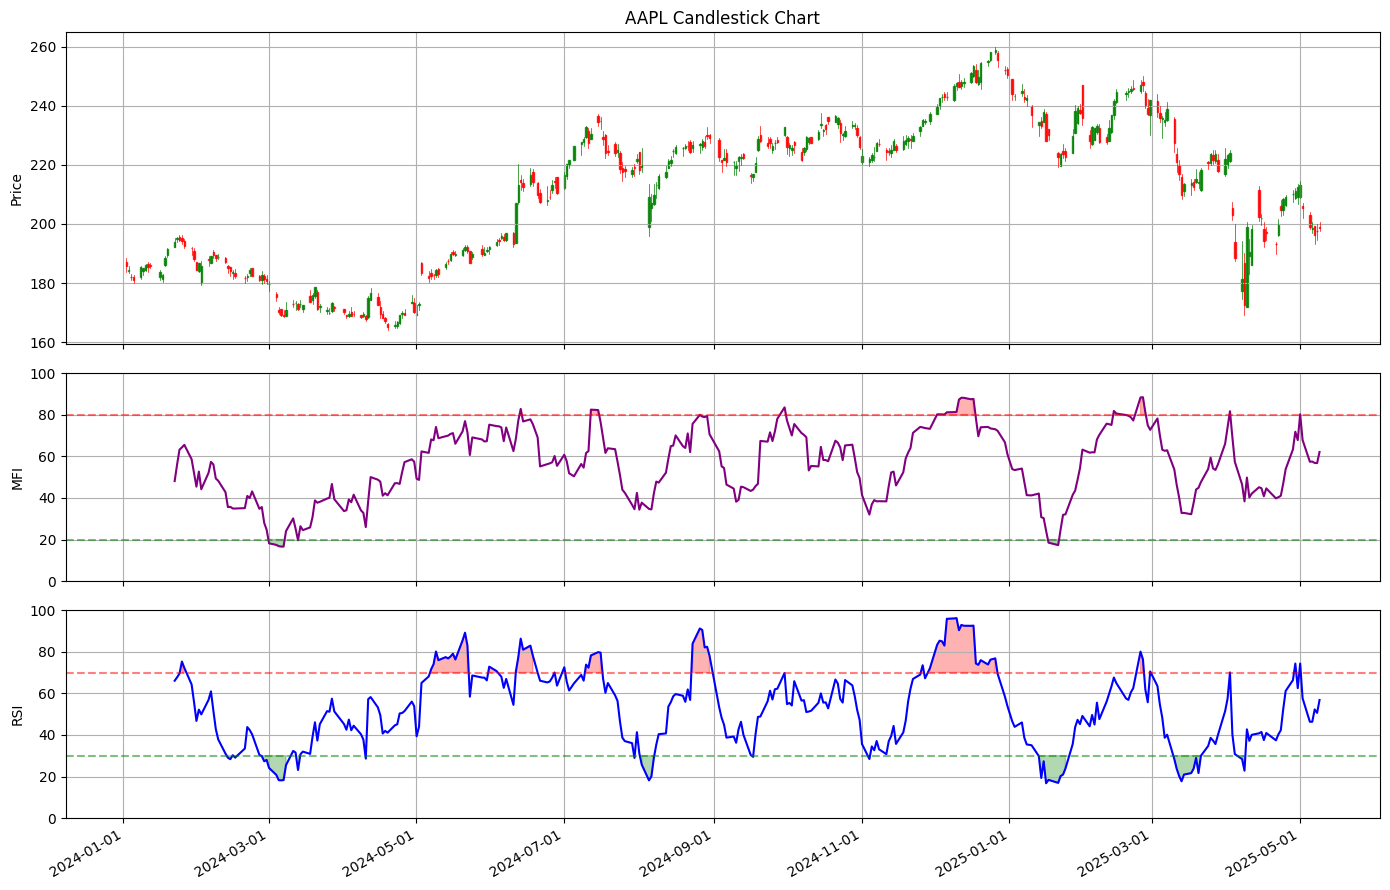

In [43]:
# Example usage
symbol = "AAPL"
start_date = "2024-01-1"
end_date = "2025-05-12"
timeframe_unit = "Day"  # "Day", "Minute", "Hour"
multiplier = 1
# Get stock data
df = get_stock_data(symbol, start_date, end_date, timeframe_unit, multiplier)

# Calculate MFI
df_with_mfi = calculate_mfi(df)

# Calculate RSI
df_with_rsi = calculate_rsi(df)

# Plot candlestick chart with volume
plot_candlesticks(df, df_with_mfi, df_with_rsi, symbol)

### Plotting Equity

In [44]:
def backtest(data, initial_cash=1_000, transaction_cost=0):
    in_position = False
    cash = initial_cash
    entry_price = 0
    trade_log = []
    equity_curve = []

    for i in range(1, len(data)):
        signal = data['signal'].iloc[i]
        price = data['close'].iloc[i]
        timestamp = data.index[i]

        # Track equity at each time step
        equity_curve.append((timestamp, cash))

        if signal == 1 and not in_position:
            entry_price = price
            in_position = True
            trade_log.append({
                'timestamp': timestamp,
                'action': 'buy',
                'price': price
            })

        elif signal == -1 and in_position:
            pnl = price - entry_price
            cash += pnl
            in_position = False
            trade_log.append({
                'timestamp': timestamp,
                'action': 'sell',
                'price': price,
                'pnl': pnl,
                'cash': cash
            })

    # Final equity entry
    if len(data) > 0:
        equity_curve.append((data.index[-1], cash))

    # Convert to pandas Series
    index = [ts[1] if isinstance(ts, tuple) else ts for (ts, _) in equity_curve]
    equity_series = pd.Series(
        data=[val for (_, val) in equity_curve],
        index=pd.to_datetime(index)
    )

    return equity_series, trade_log

In [45]:
def plot_equity_curve(equity_rsi, equity_mfi, equity_combined):
    plt.figure(figsize=(15, 6))
    plt.plot(equity_rsi, label='Equity Curve', linewidth=2)
    plt.title("RSI Strategy Equity Curve")
    plt.xlabel("Time")
    plt.ylabel("Cash / Equity")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(15, 6))
    plt.plot(equity_mfi, label='Equity Curve', linewidth=2)
    plt.title("MFI Strategy Equity Curve")
    plt.xlabel("Time")
    plt.ylabel("Cash / Equity")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(15, 6))
    plt.plot(equity_combined, label='Equity Curve', linewidth=2)
    plt.title("COMBINED Strategy Equity Curve")
    plt.xlabel("Time")
    plt.ylabel("Cash / Equity")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

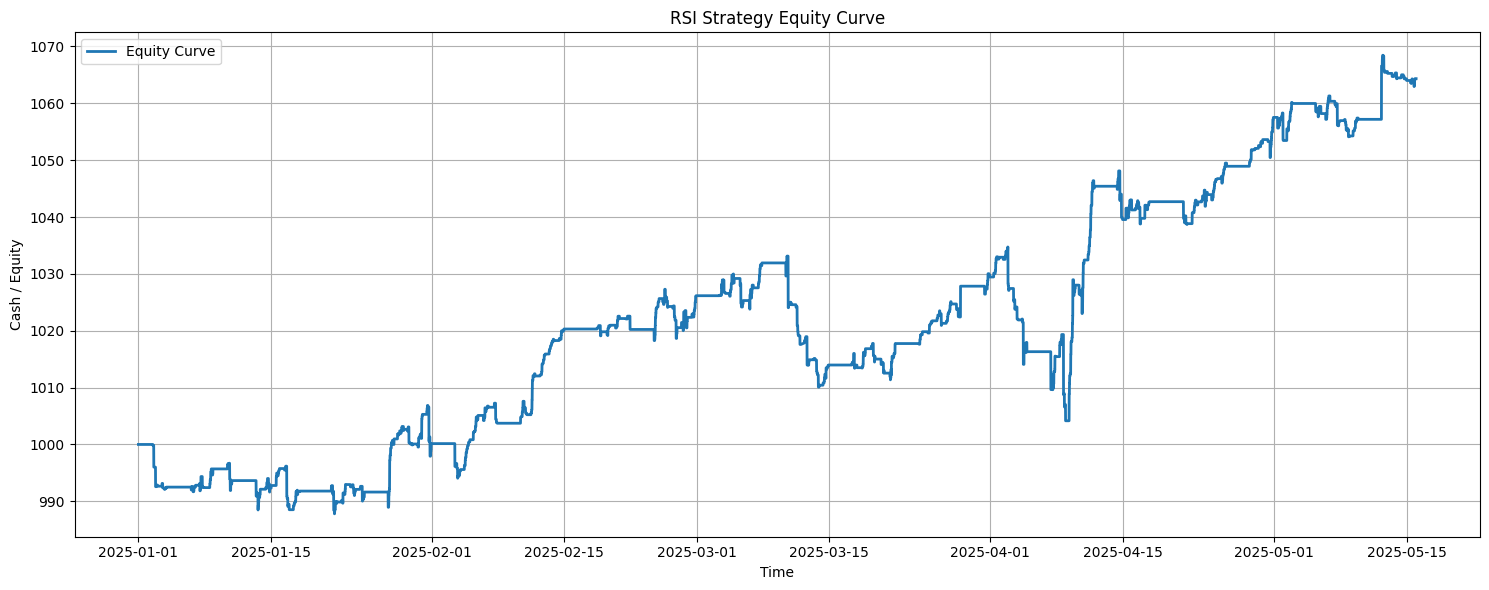

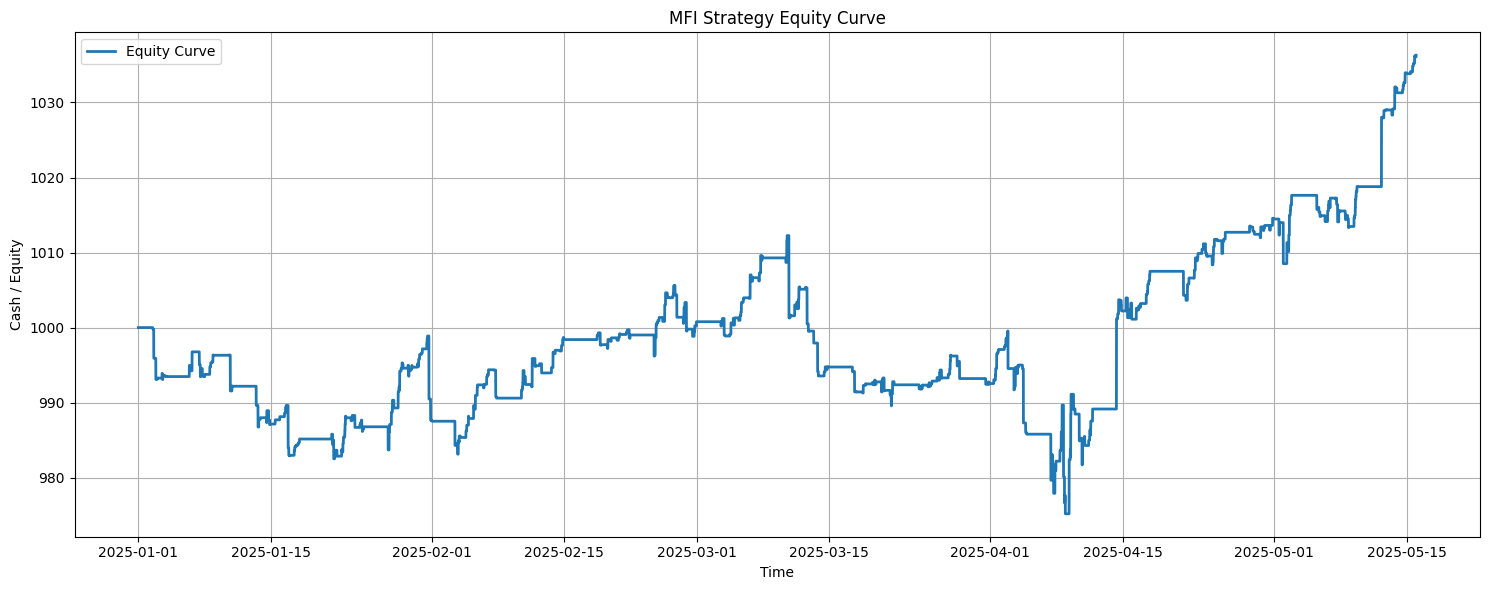

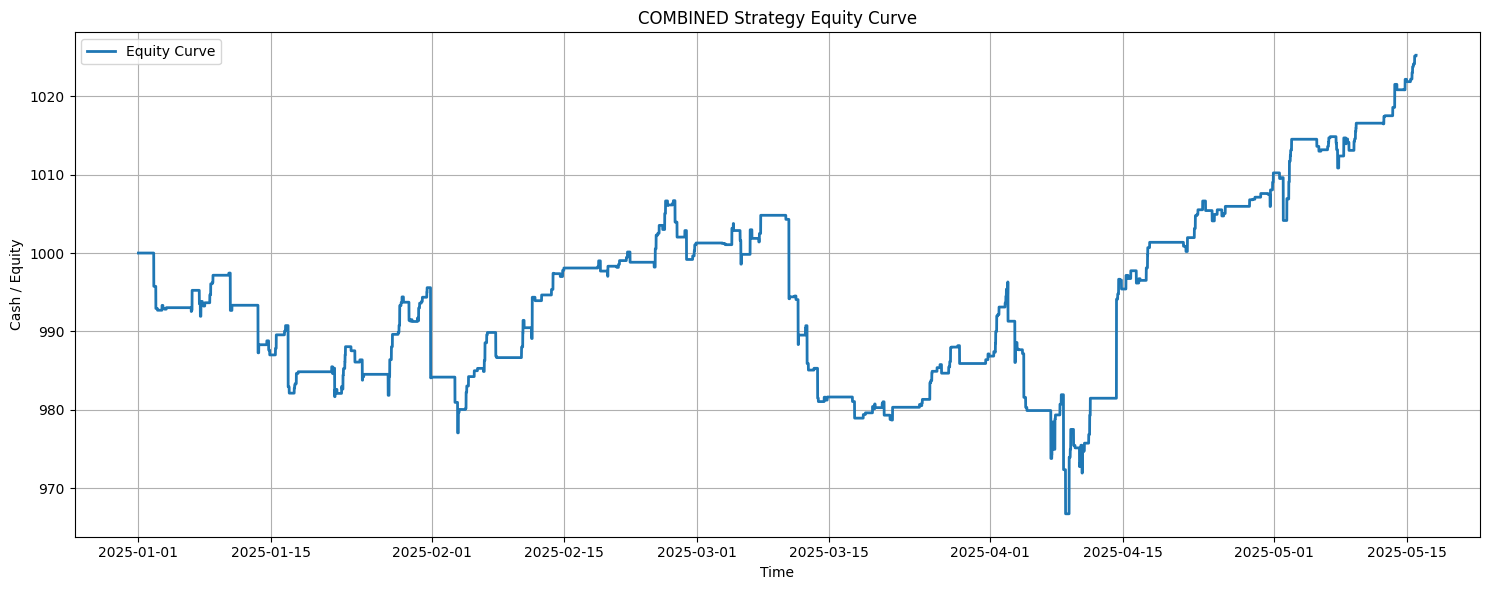

In [46]:
df = get_stock_data("AAPL", "2025-01-01", "2025-05-16", "Minute", 1)

# RSI
signals = generate_signals_rsi(df)
equity_rsi, trades = backtest(signals)

# MFI
signals = generate_signals_mfi(df)
equity_mfi, trades = backtest(signals)

# Combined
signals = generate_combined_signal(df)
equity_combined, trades = backtest(signals)

plot_equity_curve(equity_rsi, equity_mfi, equity_combined)

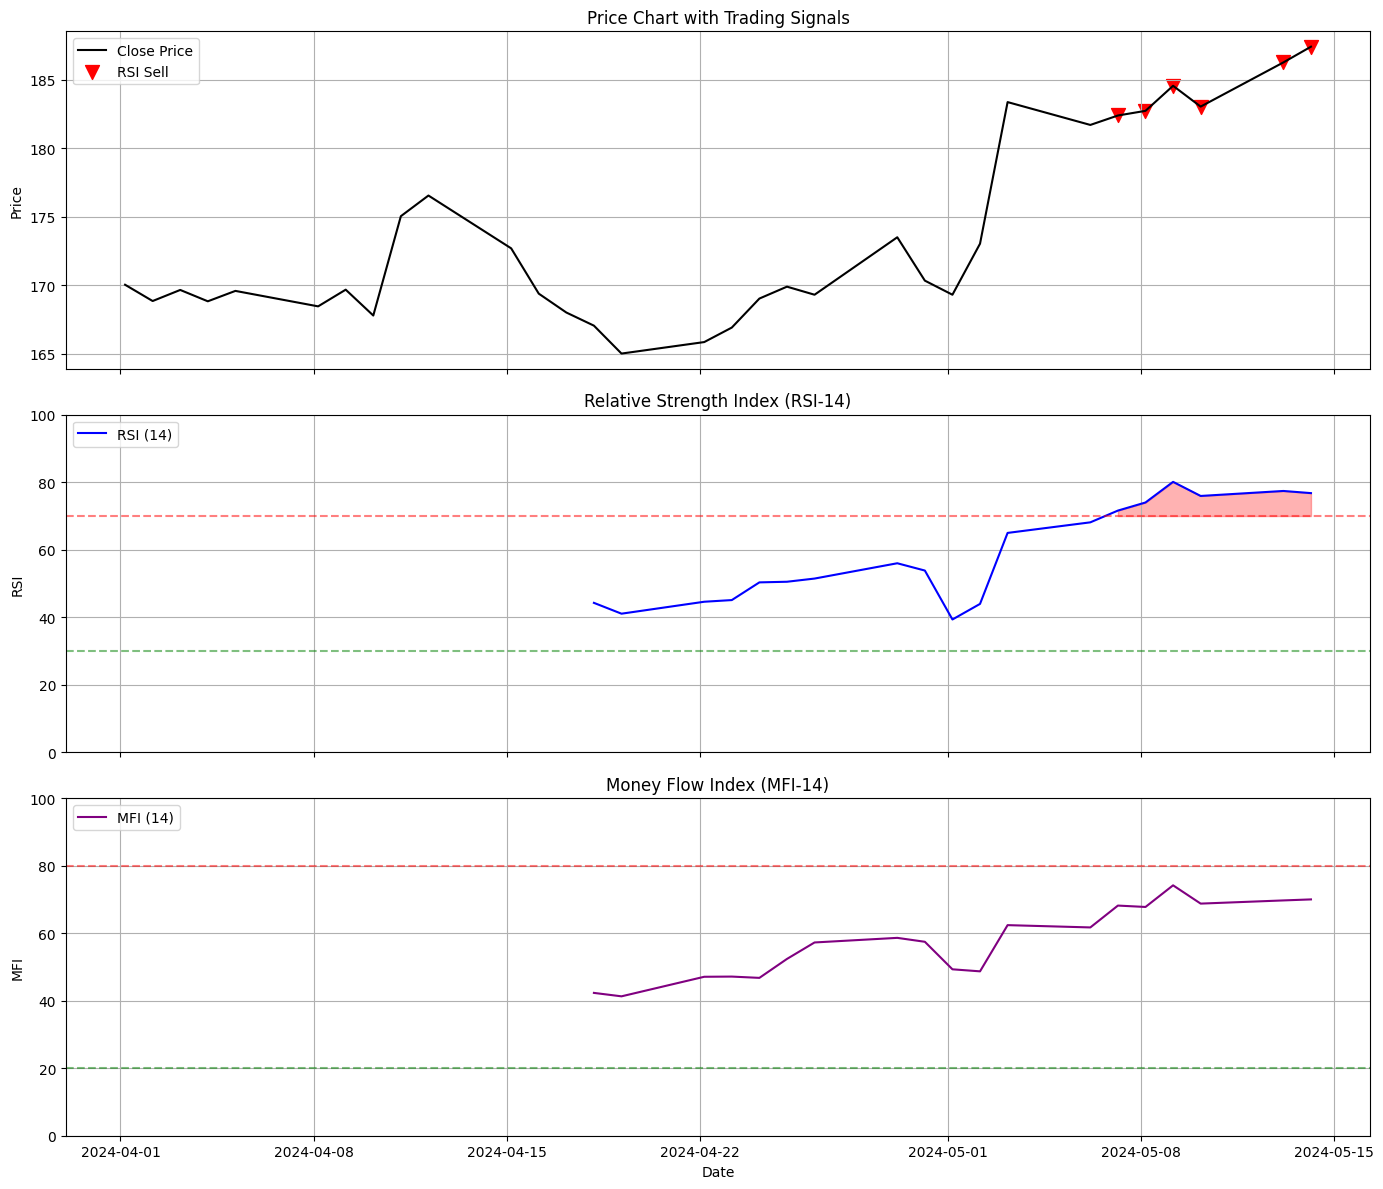

RSI Buy Signals: 0
RSI Sell Signals: 6
MFI Buy Signals: 0
MFI Sell Signals: 0
Combined Buy Signals: 0
Combined Sell Signals: 0


In [47]:
# Get data
df = get_stock_data("AAPL", "2024-04-01", "2024-05-15", "Day", 1)

# Plot comparison of indicators
plot_indicators_comparison(df)
